# Perfil de Comunicación de Entrenadores de Fútbol mediante Topic Modeling

**Trabajo Práctico Integrador — Procesamiento de Lenguaje Natural**
Ingeniería en Inteligencia Artificial · Universidad de Palermo

---

## 1. Introducción

Las conferencias de prensa de los entrenadores de fútbol son una fuente rica de
información sobre **cómo comunica** un DT: de qué temas habla, en qué proporción y
cómo cambia su discurso. Hoy ese análisis se hace de forma manual y subjetiva.

**Tarea de NLP elegida (una sola): Topic Modeling.**

Reformulamos el objetivo —"perfil de comunicación del DT"— como un problema de
topic modeling:

> El perfil de comunicación de un entrenador = la **distribución de tópicos** latentes
> en su discurso + su **evolución** + un **descriptor de sentimiento** por tópico.

El topic modeling es el núcleo metodológico; el perfil es la capa de aplicación.

**Metodología (toda del APUNTE 7 de la cursada):**
- **BERTopic** (Sentence-BERT + UMAP + HDBSCAN/K-means + c-TF-IDF) — modelo principal.
- **LDA** (gensim) — baseline.
- **Coherencia c_v** — métrica para comparar y elegir el nº de tópicos.
- `pysentimiento` — descriptor de sentimiento (secundario).

## 2. Configuración

El notebook reutiliza los módulos del backend (`app/`).

In [1]:
import sys
from pathlib import Path

# Hacer visible el paquete del backend
BACKEND = Path.cwd().parent / "backend"
sys.path.insert(0, str(BACKEND))

import pandas as pd
import matplotlib.pyplot as plt

from app import transcription, preprocess, topic_model, profile

pd.set_option("display.max_colwidth", 80)
print("Módulos cargados.")

Módulos cargados.


## 3. Dataset

Corpus propio de transcripciones de conferencias de prensa de DTs del fútbol
argentino, generado con el pipeline de ingesta (yt-dlp + Whisper). Los transcripts
están en `data/transcripts/`.

> Para agregar conferencias nuevas: `transcription.process_url("<link de YouTube>", coach="<DT>")`

In [2]:
records = transcription.load_transcripts()
df = pd.DataFrame([
    {"DT": r.get("coach"), "conferencia": r.get("title"),
     "caracteres": len(r.get("text", "")), "segmentos": len(r.get("segments", []))}
    for r in records
])
print(f"Conferencias en el corpus: {len(records)}")
df

Conferencias en el corpus: 3


,DT,conferencia,caracteres,segmentos
0,Nicolás Diez,"🎤🔥 EXPLOSIVA conferencia de Nicolás Diez, tras la eliminación de #AAAJ frent...",7854,75
1,Bielsa,La APLAUDIDA REFLEXIÓN de BIELSA en rueda de prensa sobre los ENTRENADORES e...,1540,37
2,Ramón Díaz,🗣️🔥 ¡TOP 10 MEJORES CHICANAS DE RAMÓN DÍAZ!,2352,58


In [3]:
# Ejemplo de transcripción (primeros 500 caracteres)
print(records[0]["coach"], "—", records[0]["title"], "\n")
print(records[0]["text"][:500], "…")

Nicolás Diez — 🎤🔥 EXPLOSIVA conferencia de Nicolás Diez, tras la eliminación de #AAAJ frente a #Belgrano x penales 

Al final le dieron el protagonismo a Belengano que no venía teniendo, porque hasta ese momento no generó situaciones de gol, quiero saber obviamente cómo lo viste vos y si pueden contar que pensaste. Yo no voy a analizar mucho el partido porque en realidad si pone defensores y no va a ganar, vas a decir que me quetran, si pongo delantero vas a decir que si va a ganar, estamos siempre también muchachos. Miren el partido bien y fíjense quién fue el protagonista del partido, quién mereció ganar, pa …


## 4. Preprocesamiento

- **Segmentación en oraciones**: cada oración es la unidad de documento del topic modeling.
- **Tokens de contenido** (sustantivos, verbos, adjetivos, propios), lematizados y sin
  stopwords ni muletillas — usados para LDA y para la coherencia c_v.

In [4]:
sentences, meta = [], []
for r in records:
    for s in preprocess.split_sentences(r["text"]):
        sentences.append(s)
        meta.append({"coach": r.get("coach") or "Desconocido",
                     "conf": r.get("title") or r.get("url")})

print(f"Oraciones totales: {len(sentences)}\n")
print("Ejemplo de oración:\n ", sentences[0])
print("\nTokens de contenido de esa oración:\n ", preprocess.content_tokens(sentences[0]))

Oraciones totales: 92

Ejemplo de oración:
  Al final le dieron el protagonismo a Belengano que no venía teniendo, porque hasta ese momento no generó situaciones de gol, quiero saber obviamente cómo lo viste vos y si pueden contar que pensaste.

Tokens de contenido de esa oración:
  ['protagonismo', 'belengano', 'venir', 'tener', 'generar', 'situación', 'gol', 'querer', 'contar', 'pensastar']


## 5. Topic Modeling con BERTopic (modelo principal)

BERTopic genera embeddings de las oraciones con Sentence-BERT, reduce dimensionalidad
con UMAP, las agrupa (HDBSCAN automático o K-means con nº fijo) y describe cada tópico
con c-TF-IDF.

In [5]:
# n_topics=None -> HDBSCAN descubre el nº de tópicos automáticamente.
# Para corpus chicos de texto corto, fijar n_topics (K-means) suele dar tópicos
# más interpretables. Probamos ambos.
tmodel, topics = topic_model.fit_bertopic(sentences, n_topics=5)
topic_words = topic_model.bertopic_topic_words(tmodel, topn=10)

for tid, words in topic_words.items():
    print(f"Tópico {tid}: {', '.join(words)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tópico 0: fútbol, hincha, volante, semana, gol, partido, minutos, hablar, analizar, central
Tópico 1: partido, equipo, tiempo, jugadores, gente, tuvimos, acá, campeonato, chance, partidos
Tópico 2: boca, ríbe, jugar, argentina, jugado, juega, habíamos, pibes, partido, gente
Tópico 3: ríbe, gustaría, habíamos, pibes, penales, ganado, poquito, contar, espectáculo, florentín
Tópico 4: repite, razón, jugada repite, explicación, empates, distintos, jugada, cosas, viene, rival


In [6]:
# Tamaño de cada tópico
info = tmodel.get_topic_info()[["Topic", "Count", "Name"]]
info

,Topic,Count,Name
0,0,28,0_fútbol_hincha_volante_semana
1,1,24,1_partido_equipo_tiempo_jugadores
2,2,14,2_boca_ríbe_jugar_argentina
3,3,13,3_ríbe_gustaría_habíamos_pibes
4,4,13,4_repite_razón_jugada repite_explicación


### Coherencia c_v del modelo BERTopic

In [7]:
tokenized = preprocess.tokenize_corpus(sentences)
cv_bertopic = topic_model.coherence_cv(list(topic_words.values()), tokenized)
print(f"Coherencia c_v (BERTopic): {cv_bertopic:.4f}")

Coherencia c_v (BERTopic): 0.2981


## 6. Baseline: LDA y selección del número de tópicos

Ajustamos LDA (gensim) variando el número de tópicos *k* y elegimos el *k* que
maximiza la coherencia c_v.

Mejor k = 8  (c_v = 0.4737)


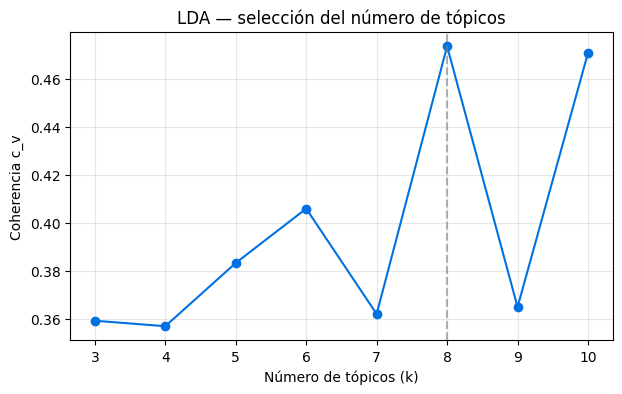

In [8]:
lda_search = topic_model.search_lda_k(tokenized, ks=range(3, 11))
sdf = pd.DataFrame(lda_search)
best = sdf.loc[sdf["coherence_cv"].idxmax()]
print(f"Mejor k = {int(best['k'])}  (c_v = {best['coherence_cv']:.4f})")

plt.figure(figsize=(7, 4))
plt.plot(sdf["k"], sdf["coherence_cv"], "o-", color="#0071e3")
plt.axvline(best["k"], ls="--", color="gray", alpha=.6)
plt.xlabel("Número de tópicos (k)"); plt.ylabel("Coherencia c_v")
plt.title("LDA — selección del número de tópicos"); plt.grid(alpha=.3); plt.show()

## 7. Comparación BERTopic vs LDA

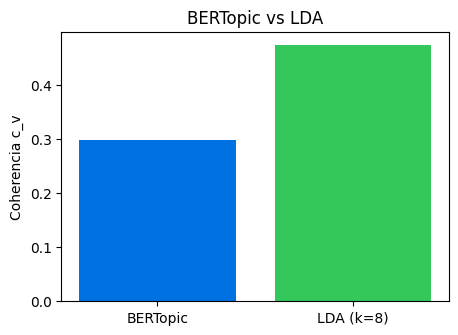

,modelo,coherencia_cv
0,BERTopic,0.298057
1,LDA (k=8),0.473650


In [9]:
lda, _, _ = topic_model.fit_lda(tokenized, int(best["k"]))
cv_lda = topic_model.coherence_cv(topic_model.lda_topic_words(lda), tokenized)

comp = pd.DataFrame({"modelo": ["BERTopic", f"LDA (k={int(best['k'])})"],
                     "coherencia_cv": [cv_bertopic, cv_lda]})
plt.figure(figsize=(5, 3.5))
plt.bar(comp["modelo"], comp["coherencia_cv"], color=["#0071e3", "#34c759"])
plt.ylabel("Coherencia c_v"); plt.title("BERTopic vs LDA"); plt.show()
comp

## 8. Perfil de Comunicación del DT (capa de aplicación)

Sobre el topic modeling construimos el perfil: distribución de tópicos por entrenador,
sentimiento por tópico y evolución conferencia a conferencia.

In [10]:
prof = profile.build_profile(records, n_topics=5, run_lda=False)
print(f"Oraciones: {prof['n_sentences']} | Tópicos: {len(prof['topics'])} | "
      f"c_v BERTopic: {prof['coherence']['bertopic_cv']}")

topics_df = pd.DataFrame([
    {"tópico": t["id"], "etiqueta": t["label"], "peso_%": round(t["share"]*100, 1),
     "POS": t["sentiment"].get("POS", 0), "NEU": t["sentiment"].get("NEU", 0),
     "NEG": t["sentiment"].get("NEG", 0)}
    for t in prof["topics"]
])
topics_df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Oraciones: 92 | Tópicos: 5 | c_v BERTopic: 0.2981


,tópico,etiqueta,peso_%,POS,NEU,NEG
0,0,fútbol · hincha · volante,30.4,0.0714,0.6786,0.2500
1,1,partido · equipo · tiempo,26.1,0.3750,0.2917,0.3333
2,2,boca · ríbe · jugar,15.2,0.3571,0.5000,0.1429
3,3,ríbe · gustaría · habíamos,14.1,0.0769,0.8462,0.0769
4,4,repite · razón · jugada repite,14.1,0.0769,0.4615,0.4615


In [11]:
# Distribución de tópicos por DT (heatmap simple)
labels = {t["id"]: t["label"] for t in prof["topics"]}
rows = []
for coach, p in prof["coaches"].items():
    row = {"DT": coach}
    for tid, share in p["topic_distribution"].items():
        row[labels.get(int(tid), tid)] = round(share*100, 1)
    rows.append(row)
dist = pd.DataFrame(rows).set_index("DT").fillna(0)
dist

,partido · equipo · tiempo,fútbol · hincha · volante,boca · ríbe · jugar,ríbe · gustaría · habíamos,repite · razón · jugada repite
DT,,,,,
Nicolás Diez,41.7,30.6,5.6,13.9,8.3
Bielsa,4.8,66.7,0.0,0.0,28.6
Ramón Díaz,22.9,8.6,34.3,22.9,11.4


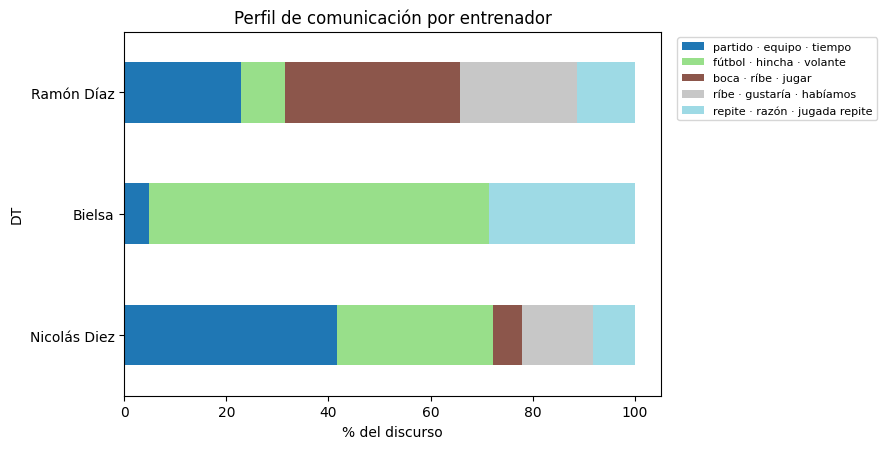

In [12]:
# Perfil de cada DT como barras apiladas
ax = dist.plot(kind="barh", stacked=True, figsize=(9, 1.2*len(dist)+1),
               colormap="tab20")
ax.set_xlabel("% del discurso"); ax.set_title("Perfil de comunicación por entrenador")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

In [13]:
# Sentimiento general por DT
sent_rows = [{"DT": c, **{k: round(v*100,1) for k,v in p["sentiment"].items()}}
             for c, p in prof["coaches"].items()]
pd.DataFrame(sent_rows).set_index("DT").fillna(0)[["POS","NEU","NEG"]]

,POS,NEU,NEG
DT,,,
Nicolás Diez,25.0,47.2,27.8
Bielsa,9.5,66.7,23.8
Ramón Díaz,20.0,54.3,25.7


## 9. Discusión, limitaciones y conclusiones

**Conclusiones**
- El topic modeling permite construir un perfil objetivo y reproducible de cómo
  comunica cada entrenador, a partir de texto transcripto automáticamente.
- BERTopic produce tópicos más interpretables que LDA en texto conversacional corto;
  la coherencia c_v sirvió para comparar y para elegir el nº de tópicos.

**Limitaciones**
- Ruido de ASR (Whisper transcribe mal algunos nombres propios, p. ej. "River").
- Corpus chico: a más conferencias, tópicos más estables y mejor coherencia.
- El sentimiento es un descriptor agregado, no un análisis fino por frase.

**Trabajo futuro**
- Ampliar el corpus; normalizar nombres propios; etiquetar manualmente una muestra
  para validar la interpretación de los tópicos.